# Treinamento de modelos

In [1]:
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torchvision
from torchvision import transforms

import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "BZA_11_06_2026"
output_dir = Path("finalProject_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 42
Dispositivo: cuda
Versão do Torch: 2.11.0+cu128
Versão do Torchvision: 0.26.0+cu128
Diretório de saída: finalProject_outputs/BZA_11_06_2026


## Importação dos dados

In [2]:
from isic2018_dataset import download_isic2018, get_dataloaders

IMAGE_SIZE = 224
BATCH_SIZE = 8

download_isic2018(root="./data/isic2018")

train_loader, val_loader, test_loader = get_dataloaders(
    root="./data/isic2018",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    train_transform=transforms.ToTensor(),
    val_transform=transforms.ToTensor(),
    test_transform=transforms.ToTensor()
)


  Split: TRAIN
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Training_Input.zip …


  Extraindo train_images.zip → data/isic2018/_cache/train_images_extracted …
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Training_GroundTruth.zip …


  Extraindo train_gt.zip → data/isic2018/_cache/train_gt_extracted …

  Split: VAL
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Validation_Input.zip …


  Extraindo val_images.zip → data/isic2018/_cache/val_images_extracted …
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Validation_GroundTruth.zip …


  Extraindo val_gt.zip → data/isic2018/_cache/val_gt_extracted …

  Split: TEST
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Test_Input.zip …


  Extraindo test_images.zip → data/isic2018/_cache/test_images_extracted …
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Test_GroundTruth.zip …


  Extraindo test_gt.zip → data/isic2018/_cache/test_gt_extracted …

✓ Download concluído. Dados em: /mnt/storage_C1/bianca_zavadisk/ml2/fine-grained-ml2/data/isic2018


In [3]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, ConcatDataset

dataset = ConcatDataset([train_loader.dataset, val_loader.dataset])

labels = []
for ds in dataset.datasets:
    if hasattr(ds, "targets"):
        labels.extend(list(ds.targets))
    elif hasattr(ds, "labels"):
        labels.extend(list(ds.labels))
    else:
        # fallback (pode ser caro pois itera o dataset)
        labels.extend([lbl for _, lbl in ds])

# Stratified split no dataset concatenado
train_idx, val_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.15,
    stratify=labels,
    random_state=seed,
)

train_subset = Subset(dataset, train_idx)
val_subset = Subset(dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [4]:
NUM_CLASSES = 7

In [5]:
benign = [1, 4, 5, 6]
malignant = [0, 2, 3]

# Cria loaders para a classificação binária

class BinaryDataset(torch.utils.data.Dataset):
    """Wrap any dataset to map multi-class labels into binary (0=benign, 1=malignant)."""
    def __init__(self, base_dataset, benign_classes, malignant_classes):
        self.base = base_dataset
        self.label_map = {}
        for c in benign_classes:
            self.label_map[int(c)] = 0
        for c in malignant_classes:
            self.label_map[int(c)] = 1

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, lbl = self.base[idx]
        # normalize label type
        lbl_val = int(lbl.item()) if isinstance(lbl, torch.Tensor) else int(lbl)
        if lbl_val not in self.label_map:
            raise KeyError(f"Label {lbl_val} not in benign/malignant mapping.")
        return img, self.label_map[lbl_val]

# Cria datasets binários mantendo exatamente as mesmas partições (subsets) usadas antes
train_binary_ds = BinaryDataset(train_loader.dataset, benign, malignant)
val_binary_ds = BinaryDataset(val_loader.dataset, benign, malignant)
test_binary_ds = BinaryDataset(test_loader.dataset, benign, malignant)

# Cria DataLoaders para classificação binária
train_binary_loader = DataLoader(train_binary_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_binary_loader = DataLoader(val_binary_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_binary_loader = DataLoader(test_binary_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

## Funções de treinamento e avaliação

### Funções de treinamento

In [81]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.best_acc = None
        self.early_stop = False

    def __call__(self, val_loss, val_acc, model):
        # Inicialização na primeira época
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_acc = val_acc
            self.save_checkpoint(model)
            return

        # Verificamos se houve melhora em QUALQUER uma das métricas
        improved_loss = val_loss < self.best_loss - self.min_delta
        improved_acc = val_acc > self.best_acc + self.min_delta

        if improved_loss or improved_acc:
            # Se a acurácia melhorou, atualizamos o recorde de acurácia
            if improved_acc:
                self.best_acc = val_acc

            # Se a loss melhorou, atualizamos o recorde de loss e salvamos
            if improved_loss:
                self.best_loss = val_loss

            # Se houve qualquer melhora, resetamos o contador e salvamos o estado
            self.save_checkpoint(model)
            self.counter = 0
        else:
            # Se nenhuma das duas melhorou, incrementa o contador
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} de {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        '''Salva o modelo quando há melhora nas métricas monitoradas.'''
        torch.save(model.state_dict(), self.path)

In [82]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device, epoch_idx=None, writer=None, model_type="model"):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    desc = f"Epoch {epoch_idx}" if epoch_idx else "Train"
    loop = tqdm(loader, desc=desc, leave=False)

    for batch_idx, (inputs, labels) in enumerate(loop, start=1):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)

        predicted_cpu = predicted.cpu()
        labels_cpu = labels.cpu()

        total += labels_cpu.size(0)
        correct += predicted_cpu.eq(labels_cpu).sum().item()

        current_loss = total_loss / total
        current_acc = correct / total
        loop.set_postfix(loss=f"{current_loss:.4f}", acc=f"{current_acc:.4f}")

        if writer is not None:
            global_step = (epoch_idx - 1) * len(loader) + batch_idx if epoch_idx else batch_idx
            writer.add_scalar(f'{model_type}/batch_loss', loss.item(), global_step)
            if batch_idx == 1:
                try:
                    imgs = inputs.detach().cpu()[:4]
                    writer.add_images(f'{model_type}/examples', imgs, epoch_idx)
                except Exception:
                    pass

        del outputs, loss, predicted, inputs, labels, predicted_cpu, labels_cpu
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / total
    return avg_loss, accuracy

In [83]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * inputs.size(0)
        
        _, predicted = outputs.max(1)
        predicted = predicted.cpu()
        labels_cpu = labels.cpu()

        total += labels_cpu.size(0)
        correct += predicted.eq(labels_cpu).sum().item()

        del outputs, loss, predicted, labels, inputs, labels_cpu
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / total
    return avg_loss, accuracy

In [84]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, model_type="", use_early_stopping = True, patience=5, student_run_tag=student_run_tag):
    from torch.utils.tensorboard import SummaryWriter 
    writer = SummaryWriter(log_dir=f'./{output_dir}/{student_run_tag}/runs/{model_type}')

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    if use_early_stopping:
        early_stopping = EarlyStopping(patience=patience, path=f'./{output_dir}/{student_run_tag}/best_model_{model_type}.pth')

    def _confusion_matrix_figure(y_true, y_pred, class_map=None, normalize=True, cmap='Blues'):
        import numpy as _np
        import matplotlib.pyplot as _plt
        from sklearn.metrics import confusion_matrix as _confusion_matrix

        classes = _np.unique(_np.concatenate([y_true, y_pred]))
        if len(classes) == 0:
            fig = _plt.figure(figsize=(4, 3))
            _plt.text(0.5, 0.5, "No data", ha='center', va='center')
            return fig

        cm = _confusion_matrix(y_true, y_pred, labels=classes, normalize='true' if normalize else None)

        fig, ax = _plt.subplots(figsize=(6, 5))
        im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        if class_map is not None:
            tick_labels = [class_map.get(int(c), str(int(c))) for c in classes]
        else:
            tick_labels = [str(int(c)) for c in classes]

        ax.set_xticks(_np.arange(len(classes)))
        ax.set_yticks(_np.arange(len(classes)))
        ax.set_xticklabels(tick_labels, rotation=45)
        ax.set_yticklabels(tick_labels)

        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.0 if cm.size > 0 else 0.5
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                val = cm[i, j]
                s = f"{val:{fmt}}" if normalize else f"{int(val)}"
                ax.text(j, i, s, ha="center", va="center",
                        color="white" if val > thresh else "black")

        ax.set_ylabel('True label')
        ax.set_xlabel('Predicted label')
        fig.tight_layout()
        return fig

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            epoch_idx=epoch+1, writer=writer, model_type=model_type
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

        if use_early_stopping:
            early_stopping(val_loss, val_acc, model)

        writer.add_scalar(f'{model_type}/train_loss', train_loss, epoch) 
        writer.add_scalar(f'{model_type}/train_acc', train_acc, epoch) 
        writer.add_scalar(f'{model_type}/val_loss', val_loss, epoch) 
        writer.add_scalar(f'{model_type}/val_acc', val_acc, epoch)

        # calcula e registra matriz de confusão da validação no tensorboard
        try:
            import numpy as np
            model.eval()
            y_true = []
            y_pred = []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs = inputs.to(device, non_blocking=True)
                    labels = labels.to(device, non_blocking=True)
                    outputs = model(inputs)

                    if outputs.dim() == 1 or outputs.shape[1] == 1:
                        probs = torch.sigmoid(outputs.view(-1))
                        preds = (probs > 0.5).long().cpu().numpy()
                    else:
                        preds = outputs.argmax(dim=1).cpu().numpy()

                    y_pred.append(preds)
                    y_true.append(labels.cpu().numpy())

                    del outputs, inputs, labels
                    if device.type == 'cuda':
                        torch.cuda.empty_cache()

            if len(y_true) > 0:
                y_true = np.concatenate(y_true)
                y_pred = np.concatenate(y_pred)
                fig = _confusion_matrix_figure(y_true, y_pred, normalize=True)
                writer.add_figure(f'{model_type}/confusion_matrix', fig, epoch)
                import matplotlib.pyplot as plt
                plt.close(fig)
        except Exception as e:
            print(f"Warning: não foi possível registrar matriz de confusão no tensorboard: {e}")

        if use_early_stopping and early_stopping.early_stop:
            print("Early stopping interrompendo o treino...")
            break

    # Carrega o melhor estado do modelo antes de retornar
    # if use_early_stopping:
    #     model.load_state_dict(torch.load(f'./{output_dir}/{student_run_tag}/best_model_{model_type}.pth'))

    writer.close()

    return history

### Funções de avaliação

In [85]:
def compute_metrics(outputs, labels):
    """
    Computa métricas relevantes para classificação como
    acurácia, precisão, recall e F1-score.
    """
    preds = outputs.argmax(dim=1)
    accuracy = (preds == labels).float().mean()
    precision = torch.sum((preds == 1) & (labels == 1)) / (torch.sum(preds == 1) + 1e-8)
    recall = torch.sum((preds == 1) & (labels == 1)) / (torch.sum(labels == 1) + 1e-8)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

    print(f"Accuracy: {accuracy.item():.4f}")
    print(f"Precision: {precision.item():.4f}")
    print(f"Recall: {recall.item():.4f}")
    print(f"F1 Score: {f1_score.item():.4f}")

In [86]:
def evaluate_classification(model, loader):
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            compute_metrics(outputs, labels)

            del outputs, labels
            if device.type == 'cuda':
                torch.cuda.empty_cache()


In [87]:
def evaluate_classification(model, loader, device=device):
    """
    Avalia o modelo sobre o loader e computa métricas agregadas:
    accuracy, balanced_accuracy, precision/recall/f1 por classe, confusion matrix e ROC AUC (quando aplicável).
    Retorna um dict com as métricas.
    """
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            # trata casos binário (1 saída ou 2 saídas) e multiclass (>=2 saídas)
            if outputs.dim() == 1 or outputs.shape[1] == 1:
                probs = torch.sigmoid(outputs.view(-1))
                preds = (probs > 0.5).long()
                all_probs.append(probs.cpu())
                all_preds.append(preds.cpu())
            else:
                probs_all = torch.softmax(outputs, dim=1)
                preds = outputs.argmax(dim=1)
                # para problema binário multiclass-style, pega prob da classe 1
                if outputs.shape[1] == 2:
                    all_probs.append(probs_all[:, 1].cpu())
                else:
                    all_probs.append(probs_all.cpu())  # multiclass scores, usado apenas se necessário
                all_preds.append(preds.cpu())

            all_labels.append(labels.cpu())

            del outputs, images, labels
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    import numpy as np
    from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                                 precision_recall_fscore_support,
                                 confusion_matrix, roc_auc_score, classification_report)

    y_true = np.concatenate([t.numpy() for t in all_labels])
    y_pred = np.concatenate([t.numpy() for t in all_preds])

    metrics = {}
    metrics['accuracy'] = float(accuracy_score(y_true, y_pred))
    metrics['balanced_accuracy'] = float(balanced_accuracy_score(y_true, y_pred))

    # per-class precision/recall/f1 and support
    precisions, recalls, f1s, supports = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    per_class = {}
    classes = np.unique(np.concatenate([y_true, y_pred]))
    for i, cls in enumerate(classes):
        per_class[int(cls)] = {
            'precision': float(precisions[i]),
            'recall': float(recalls[i]),
            'f1': float(f1s[i]),
            'support': int(supports[i])
        }
    metrics['per_class'] = per_class

    # aggregated macro/binary metrics
    avg = 'binary' if len(classes) == 2 else 'macro'
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=avg, zero_division=0)
    metrics.update({'precision': float(precision), 'recall': float(recall), 'f1': float(f1)})

    metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred).tolist()

    # tenta ROC AUC quando for binário e tivermos scores adequados
    try:
        if len(all_probs) > 0:
            probs_cat = np.concatenate([p.numpy() for p in all_probs])
            if probs_cat.ndim == 1:
                metrics['roc_auc'] = float(roc_auc_score(y_true, probs_cat))
            elif probs_cat.ndim == 2 and probs_cat.shape[1] == 2:
                metrics['roc_auc'] = float(roc_auc_score(y_true, probs_cat[:, 1]))
            else:
                metrics['roc_auc'] = None
        else:
            metrics['roc_auc'] = None
    except Exception:
        metrics['roc_auc'] = None

    # relatório resumido
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"Precision ({avg}): {metrics['precision']:.4f}")
    print(f"Recall ({avg}): {metrics['recall']:.4f}")
    print(f"F1 ({avg}): {metrics['f1']:.4f}")
    if metrics['roc_auc'] is not None:
        print(f"ROC AUC: {metrics['roc_auc']:.4f}")
    print("Confusion matrix:")
    print(np.array(metrics['confusion_matrix']))
    print("Per-class metrics:")
    for cls, m in metrics['per_class'].items():
        print(f" Class {cls}: precision={m['precision']:.3f}, recall={m['recall']:.3f}, f1={m['f1']:.3f}, support={m['support']}")

    return metrics

In [88]:
def plot_roc(model, loader, device, type='binary'):
    """
    Plota a curva ROC para o modelo.
    """
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize

    y_true = []
    y_scores = []

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            # mover tensores para o mesmo device do modelo
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            # calcula probabilidades compatíveis com binário/multiclass
            if outputs.dim() == 1 or outputs.shape[1] == 1:
                probs = torch.sigmoid(outputs.view(-1)).cpu().numpy()
                y_scores.extend(probs)
            else:
                probs_all = torch.softmax(outputs, dim=1)
                if outputs.shape[1] == 2:
                    probs = probs_all[:, 1].cpu().numpy()
                    y_scores.extend(probs)
                else:
                    # multiclass: armazena todas as probabilidades (por classe)
                    # aqui acumulamos por batch; converteremos depois para array NxC
                    y_scores.extend(probs_all.cpu().numpy())

            y_true.extend(labels.cpu().numpy())

            del outputs, images, labels
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    import numpy as np

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    if type == 'multiclass':
        n_classes = NUM_CLASSES
        # espera y_scores shape (N, C)
        if y_scores.ndim == 1:
            raise RuntimeError("Esperado scores multiclass NxC, mas recebeu vetor unidimensional.")
        y_test_bin = label_binarize(y_true, classes=np.arange(n_classes))
        fpr = dict(); tpr = dict(); roc_auc = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_scores.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        plt.figure(figsize=(10, 8))
        plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})', color='deeppink', linestyle=':', linewidth=4)
        colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black']
        for i, color in zip(range(n_classes), colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} ROC (AUC = {roc_auc[i]:.2f})')
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.title('Multi-class One-vs-Rest (OvR) ROC Curve'); plt.legend(loc="lower right"); plt.grid(True)
        plt.show()

    else:
        # binário: y_scores deve ser vetor com prob da classe positiva
        if y_scores.ndim > 1:
            # se acumulamos matrizes por batch, podem precisar pegar coluna 1
            if y_scores.shape[1] == 2:
                y_scores = y_scores[:, 1]
            else:
                raise RuntimeError("Scores com dimensão inesperada para ROC binário.")
        fpr, tpr, thresholds = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC)'); plt.legend(loc="lower right"); plt.show()

In [89]:
def plot_eval(history, model_name, student_run_tag=student_run_tag):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    metrics = [('loss', 'Loss'), ('acc', 'Accuracy')]

    for i, (key, label) in enumerate(metrics):
        ax = axes[i]

        ax.plot(history[f'train_{key}'], label=f'Train {label}', color='darkorchid', lw=2)
        ax.plot(history[f'val_{key}'], label=f'Validation {label}', color='seagreen', lw=2)

        ax.set_title(f'Training and Validation {label} ({model_name.upper()})')
        ax.set_xlabel('Epochs')
        ax.set_ylabel(label)
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()

    save_dir = f'./{output_dir}/{student_run_tag}'
    file_path = f'{save_dir}/evaluation_curves_{model_name}.png'
    plt.savefig(file_path)
    plt.show()
    print(f'Painel de avaliação salvo em: {file_path}')

In [90]:
def plot_confusion_matrix(model, loader, device, classes=None, normalize=False, figsize=(8,6), cmap='Blues', class_map=None):
    """
    Calcula e plota a matriz de confusão para `model` sobre `loader`.
    ...
    """
    import numpy as np
    from sklearn.metrics import confusion_matrix
    import matplotlib.pyplot as plt

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            # Decide predicões a partir da saída do modelo
            if outputs.dim() == 1 or outputs.shape[1] == 1:
                probs = torch.sigmoid(outputs.view(-1))
                preds = (probs > 0.5).long().cpu().numpy()
            else:
                preds = outputs.argmax(dim=1).cpu().numpy()

            y_pred.append(preds)
            y_true.append(labels.cpu().numpy())

            del outputs, images, labels
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # Decide classes e rótulos a mostrar nos eixos
    if class_map is not None:
        # Normaliza class_map para inv_map: int_index -> name_str
        inv_map = {}
        for k, v in class_map.items():
            # tenta tratar chave como índice (int -> name)
            try:
                idx = int(k)
                inv_map[idx] = str(v)
                continue
            except Exception:
                pass
            # tenta tratar valor como índice (name -> int)
            try:
                idx = int(v)
                inv_map[idx] = str(k)
                continue
            except Exception:
                pass
            raise ValueError("class_map deve mapear int->str (ex: {0:'benigno'}) ou str->int (ex: {'benigno':0}).")
        ordered_indices = sorted(inv_map.keys())
        if classes is None:
            classes = ordered_indices
        # tick labels na mesma ordem das classes
        tick_labels = [inv_map.get(c, str(c)) for c in classes]
    else:
        # sem class_map: comportamento anterior
        if classes is None:
            try:
                classes = list(range(NUM_CLASSES))
            except Exception:
                classes = np.unique(np.concatenate([y_true, y_pred])).tolist()
        # se classes são ints, usa-os como rótulos simples
        tick_labels = [str(c) for c in classes]

    cm = confusion_matrix(y_true, y_pred, labels=classes, normalize='true' if normalize else None)

    plt.figure(figsize=figsize)
    im = plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title('Confusion matrix' + (' (normalized)' if normalize else ''))
    plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, tick_labels, rotation=45)
    plt.yticks(tick_marks, tick_labels)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.0 if cm.size > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            if normalize:
                s = f"{val:.2f}"
            else:
                s = f"{int(val)}"
            plt.text(j, i, s,
                     horizontalalignment="center",
                     color="white" if val > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    return cm

## Modelos com conexões residuais

[Código retirado](https://medium.com/biased-algorithms/building-resnet18-from-scratch-using-pytorch-64c6619432f2)

In [50]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        
        # Apply the first convolution, batch norm, and ReLU activation
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Apply the second convolution and batch norm
        out = self.conv2(out)
        out = self.bn2(out)

        # Handle downsampling if required
        if self.downsample is not None:
            identity = self.downsample(x)
        
        # Add skip connection
        out += identity
        out = self.relu(out)

        return out

In [51]:
def initialize_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

In [52]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Define the layers based on ResNet-18 architecture
        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        
        # Initialize weights
        self.apply(initialize_weights)
        
    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        layers = [ResidualBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x

In [53]:
NUM_CLASSES = 2
model_resnet = ResNet18(num_classes=NUM_CLASSES).to(device)

epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet.parameters(), lr=1e-3)

summary(model_resnet, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
    ResidualBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [54]:
history_resnet = fit(model_resnet, train_binary_loader, val_binary_loader, optimizer, criterion, device, epochs, 'resnet', False)

Epoch 1/50: Train Loss: 0.4630 | Acc: 0.8007 | Val Loss: 0.4773 | Acc: 0.8048


Epoch 2/50: Train Loss: 0.4297 | Acc: 0.8046 | Val Loss: 0.4119 | Acc: 0.8048


Epoch 3/50: Train Loss: 0.4162 | Acc: 0.8043 | Val Loss: 0.3956 | Acc: 0.8022


Epoch 4/50: Train Loss: 0.4106 | Acc: 0.8036 | Val Loss: 0.3862 | Acc: 0.8048


Epoch 5/50: Train Loss: 0.4081 | Acc: 0.8036 | Val Loss: 0.4075 | Acc: 0.8048


...

Epoch 46/50: Train Loss: 0.1955 | Acc: 0.9227 | Val Loss: 0.4062 | Acc: 0.8453


Epoch 47/50: Train Loss: 0.1747 | Acc: 0.9288 | Val Loss: 0.4396 | Acc: 0.8401


Epoch 48/50: Train Loss: 0.1602 | Acc: 0.9368 | Val Loss: 0.4444 | Acc: 0.8460


Epoch 49/50: Train Loss: 0.1502 | Acc: 0.9387 | Val Loss: 0.4318 | Acc: 0.8433


Epoch 50/50: Train Loss: 0.1277 | Acc: 0.9482 | Val Loss: 0.4874 | Acc: 0.8446


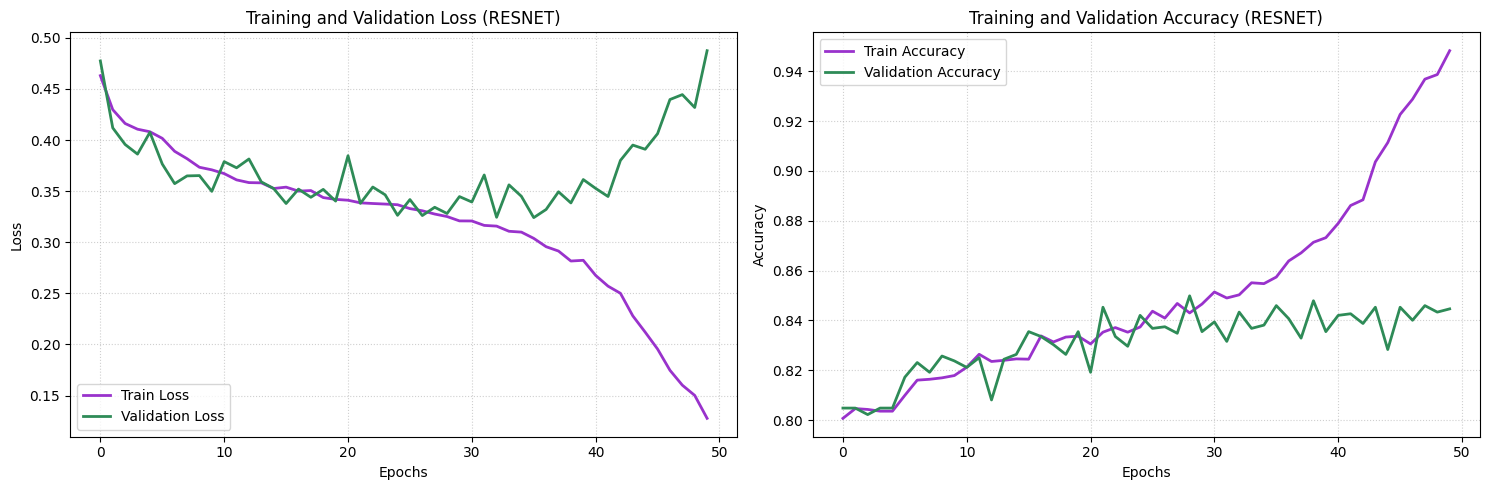

Painel de avaliação salvo em: ./finalProject_outputs/BZA_11_06_2026/evaluation_curves_resnet.png


In [57]:
torch.save(model_resnet.state_dict(), f'./{output_dir}/{student_run_tag}/model_resnet.pth')
plot_eval(history_resnet, 'resnet')

In [78]:
evaluate_classification(model_resnet, test_binary_loader)

Accuracy: 0.8181
Balanced Accuracy: 0.6941
Precision (binary): 0.5602
Recall (binary): 0.4853
F1 (binary): 0.5201
ROC AUC: 0.8318
Confusion matrix:
[[1088  117]
 [ 158  149]]
Per-class metrics:
 Class 0: precision=0.873, recall=0.903, f1=0.888, support=1205
 Class 1: precision=0.560, recall=0.485, f1=0.520, support=307


{'accuracy': 0.8181216931216931,
 'balanced_accuracy': 0.6941232919296634,
 'per_class': {0: {'precision': 0.8731942215088283,
   'recall': 0.9029045643153527,
   'f1': 0.8878008975928192,
   'support': 1205},
  1: {'precision': 0.5601503759398496,
   'recall': 0.48534201954397393,
   'f1': 0.5200698080279232,
   'support': 307}},
 'precision': 0.5601503759398496,
 'recall': 0.48534201954397393,
 'f1': 0.5200698080279232,
 'confusion_matrix': [[1088, 117], [158, 149]],
 'roc_auc': 0.8317839620473867}

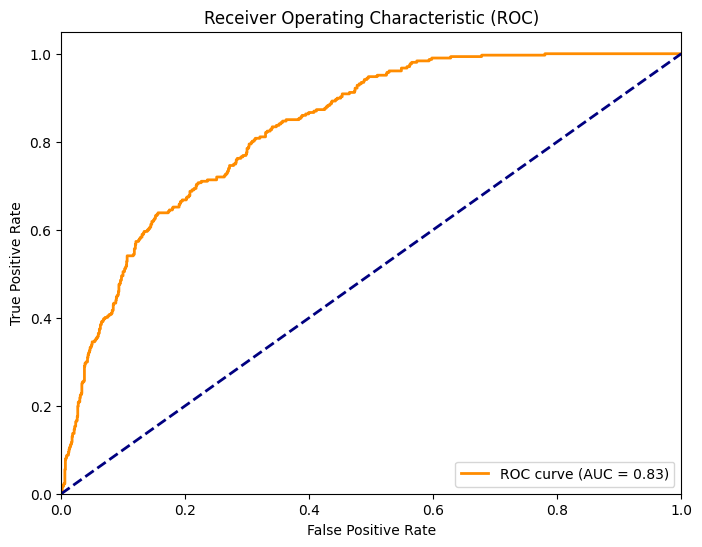

In [67]:
plot_roc(model_resnet, test_binary_loader, device, type='binary')

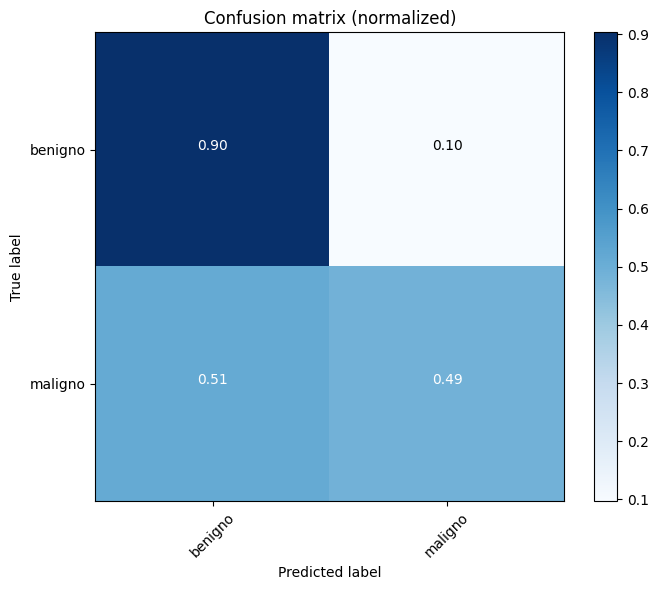

array([[0.90290456, 0.09709544],
       [0.51465798, 0.48534202]])

In [76]:
plot_confusion_matrix(model_resnet, test_binary_loader, device, classes=[0, 1], normalize=True, class_map={0: 'benigno', 1: 'maligno'})

In [91]:
NUM_CLASSES = 2
model_resnet2 = ResNet18(num_classes=NUM_CLASSES).to(device)

epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet2.parameters(), lr=1e-3)

In [92]:
history_resnet2 = fit(model_resnet2, train_binary_loader, val_binary_loader, optimizer, criterion, device, epochs, 'resnet2', False)

Epoch 1/50: Train Loss: 0.4683 | Acc: 0.7985 | Val Loss: 0.4992 | Acc: 0.8048


Epoch 2/50: Train Loss: 0.4302 | Acc: 0.8022 | Val Loss: 0.4127 | Acc: 0.8048


Epoch 3/50: Train Loss: 0.4231 | Acc: 0.8031 | Val Loss: 0.3964 | Acc: 0.8055


Epoch 4/50: Train Loss: 0.4154 | Acc: 0.8036 | Val Loss: 0.3793 | Acc: 0.8114


Epoch 5/50: Train Loss: 0.4088 | Acc: 0.8086 | Val Loss: 0.3828 | Acc: 0.8055


...

Epoch 46/50: Train Loss: 0.1099 | Acc: 0.9565 | Val Loss: 0.5083 | Acc: 0.8381


Epoch 47/50: Train Loss: 0.0926 | Acc: 0.9637 | Val Loss: 0.5423 | Acc: 0.8244


Epoch 48/50: Train Loss: 0.0789 | Acc: 0.9703 | Val Loss: 0.7873 | Acc: 0.8205


Epoch 49/50: Train Loss: 0.0650 | Acc: 0.9759 | Val Loss: 0.7461 | Acc: 0.8087


Epoch 50/50: Train Loss: 0.0651 | Acc: 0.9751 | Val Loss: 0.7883 | Acc: 0.8231


## Mitigando o overfitting